[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BartekDaniluk/Big_Data/blob/main/Neural_nets_TLDR.ipynb)


# Sztuczne Sieci Neuronowe
Jak dobrze wiemy sztuczna inteligencja zawładnęła światem, a stało się tak głównie dzięki rozwojowi sztucznych sieci neuronowych, a więc kończąc nasz wstęp do przetwarzania dużych zbiorów danych zrobimy sobie swoiste wstęp podsumowanie sieci neuronowych.

Zanim jednak zaczniemy mówić o samych sieciach, musimy sobie wytłumaczyć czym jest "nić" z której składa się owa sieć.

## Perceptorn

Nicią, podobnie jak w naszej oryginalnej sieci neuronowej, czyli mózgu, jest Neuron. Jego sztucznym odpowiednikiem jest **Perceptron**, zaproponowany w roku 1943 przez **Warren-a McCulloch-a** oraz  **Walter-a Pittsem-a**.


Jest on niczym więcej jak prostym matematycznym modelem w którym mamy wejścia (inputs)neuronu zaznaczane odpowiednia $x_1, x_2, ..., x_3$, które można porównać do dendrytów w prawdziwym neuronie. Każdemy z tych wejść przypisana jest waga (weight) odpowiednio $w_1, w_2, ..., w_3$ i to właśnie przez dostosowanie wag każdego neuronu w naszej sieci neuronowej realizowany jest jej proces uczenia, ale o tym za chwilę. Należy również wspomnieć o **bias**-ie, którego zadaniem jest przesuwanie **funkcji aktywacji** (activation function), co pozwala modelowi na uczenie się funkcji nie przechodzących przez początek układu współrzędnych (origin point).

Należy również wspomnieć o **bias**-ie, którego zadaniem jest przesuwanie **funkcji aktywacji** (activation function), co pozwala modelowi na uczenie się funkcji nie przechodzących przez początek układu współrzędnych (origin point).

Funkcję ciała komórki naszego neuronu pełni suma ważona, czyli sumowane są wszystkie wejścia (po przemnożeniu przez ich wagi) oraz bias. Wynik ten jest następnie przekazywane do jakiejś funkcji **nieliniowej** jak Sigmoid, ReLU, tanh...

A więc działanie perceptronu można ująć wzorem:

$\hat{y} = f\left(\sum_{i=1}^n w_i x_i + b\right)$
gdzie

*   $x_i$ - Wejścia neuronu
*   $w_i$ - wagi
*   $b$ - bias
*   $f$ - funkcja nieliniowa
*   $\hat{y}$ - wyjście, czyli 'wynik' neuronu,





Schemat Perceptronu

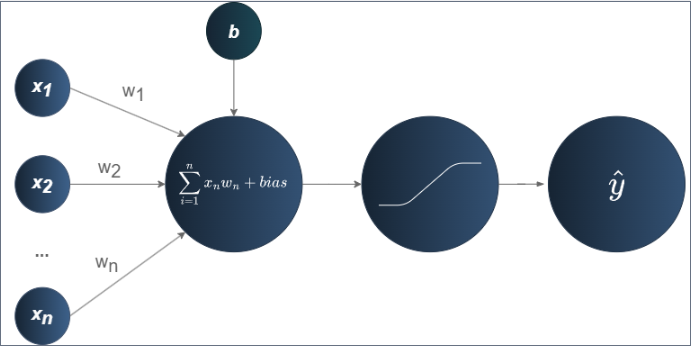

In [ ]:
import numpy as np

np.random.seed(42)

class Perceptron:
  """
  Prosty model sztucznego neuronu (Perceptronu).
  Przechowuje wagi wejść oraz bias. Oblicza sumę ważoną wejść powiększoną o bias,
  a następnie przepuszcza wynik przez funkcję aktywacji.
  """
  def __init__(self, input_size):
    self.weights = np.random.randn(input_size) # wagi inicjalizowane losowo
    self.bias = np.random.randn() # tak samo bias

  def forward(self, inputs): # forward pass, czyli przejście 'w przód neuronu'
    linear_output = np.dot(self.weights, inputs) + self.bias
    return self.activation(linear_output)

  def activation(self, x):
    return 1 / (1 + np.exp(-1*x))


input_size = 2
perceptron = Perceptron(input_size)

inputs = np.array([0.5, -1.5])  # Przykładowe wejścia
output = perceptron.forward(inputs)
print(f"Wynik: {output}")

Wynik: 0.750904489438846


## Multi-Layer Percceptron



Czyli w luźnym tłumaczeniu wielowarstwowy perceptron, jest to najprostsza sieć neuronowa, oraz termin używany zamiennie z Sztucznymi sieciami neuronowymi (Artificial Neural Networks) a przynajmniej z ich najprostszymi wariantami (feedforward neural networks). Neurony są w nich układane w warstwy:



*   Warstwę wejściową (input layer) - czyli wejścia (dane) które chcemy przemielić
*   Warstwy ukryte (hidden layers) - czyli warstwy składające się z naszych neuronów. Wejściami do poszczególnego neuronu są wyjścia wszystkich neuronów z poprzedniej powłoki, a wyjście jest przekazywane do wszystkich neuronów w następnej powłoce. Rozmiar sieci zależy od ilości i rozmiaru tych właśnie powłok
*   Warstwa wyjściowa - czyli wynik naszej sieci. Ma ona tyle neuronów ile chcemy mieć możliwych wyjść w naszej sieci, czyli np. w przypadku regresji będzie to 1 neuron, w przypadku klasyfikacji tyle neuronów ile mamy klas itd itd.

Schemat budowy sieci neuronowej dla klasyfikacji binarnej: (ilustracja po polsku więc w tym przypadku $w_1$ oznacza 'wejście 1')

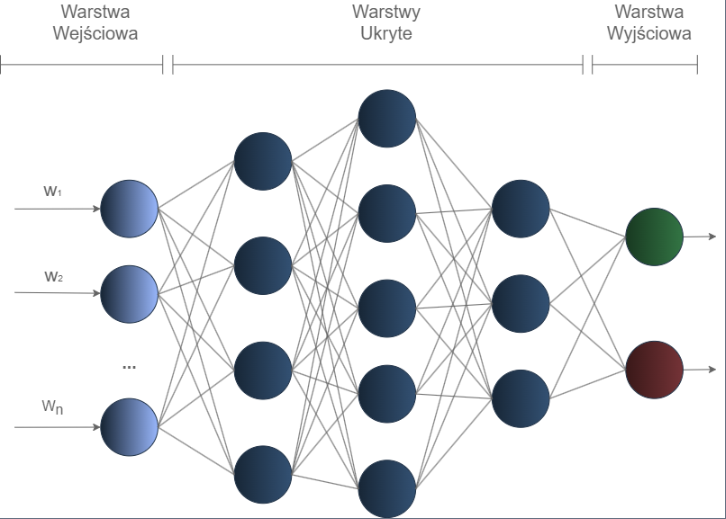


Sklejmy to teraz w kodzie, skorzystamy ze wcześniej napisanego Perceptronu




In [ ]:
# Warstwa, przechowuje neurony się w niej znajdujące
class Layer:
    def __init__(self, num_neurons, input_size):
        self.neurons = [Perceptron(input_size) for _ in range(num_neurons)]

    def forward(self, inputs): # wykonuje forward pass dla każdego z neuronów w naszej sieci i zwraca jako tablice numpy
        return np.array([neuron.forward(inputs) for neuron in self.neurons])


class MLP: # najprostszy MLP, wszystkie powłoki mają jednakowe rozmiary
    def __init__(self, layer_sizes): # kolejno podajemy rozmiary powłok
        self.layers = [
            Layer(num_neurons, input_size)
            for input_size, num_neurons in zip(layer_sizes[:-1], layer_sizes[1:]) # dopasowujemy wyjścia powłoki do wejść następnej
        ]

    def forward(self, inputs):
        current_output = inputs
        for layer in self.layers:
            current_output = layer.forward(current_output)
        return current_output

# Przykładowa sieć z powłokami kolejno 2, 3 i  1 neuron
nn = MLP([2, 3, 1])

inputs = np.array([0.5, -1.5])
output = nn.forward(inputs)
print(f"Wynik sieci: {output}")

Wynik sieci: [0.11447299]


# Trening, czyli nauka Sieci Neuronowych

zanim stworzona sieć neuronowa będzie sie nadawała do czegokolwiek musi ona przejść przez proces treningu. To właśnie w tym momencie sieć uczy się jak najlepiej, a raczej jak 'najmniej źle' wykonywać wyznaczone jej zadanie.
Trening ten odbywa się w epokach, których ilość najczęściej jest z góry ustalona przez nas, a celem naszej sieci jej poprawiać swoje wyniki z epoki na epokę.

Po zakończonym treningu (który może trwać parę sekund, minut, godzin, dni, czy nawet miesięcy) testujemy nasz gotowy model aby sprawdzić czy spełnia on nasze wymagania.

Jeśli nie to modyfikujemy architekturę naszego modelu, na różne sposoby o których powiemy później.

Sam proces uczenia się sieci polega na stopniowym dostosowywaniu **WSZYSTKICH** wag (połączeń) w naszej sieci. To właśnie to jest głównym powodem dlaczego trenowanie sieci może zajmować ogromną ilość czasu, nawet z najlepszym sprzętem. GPT 3 np posiadał 175 miliardów parametrów, a jego trening mógł zająć między 1 a 3 miesiące. Jbc nie są to oficjalne dane ale najprawdopodobniej +- się zgadzają.

Algorytmem za pomocą którego wagi te są dostosowywane jest SGD,Stochastic Gradient Descent (Stochastyczny spadek wzdłuż gradientu (ang. Stochastic Gradient Descent)). Szybki schemat działania SGD:



1.   Zbiór danych zostaje losowo wymieszany
2.   Wybierane jest tempo uczenia $\alpha$, decyduje ono jak duże kroki wykonuje nasz algorytm, zbyt niska wartość skutkuje dokładnym lecz bardzo wolnym uczeniem, czasami zbyt wolnym aby osiągnąć lokalne minimum w rozsądnym czasie, zbyt duża natomiast, mimo szybkiego tępa uczenia może podejmować zbyt duże kroki i 'przeskakiwać' nasze lokalne minimum.
3.   Wybierane są losowe wartości parametrów $\theta$ jak nasz punkt startowy.
4.   Wykonany zostaje 'forward pass', czyli przejście w przód sieci (predykcja) wraz z jej oceną
5.   Wartości parametrów zostają uaktualnione na podstawie jednej próbki $x_i, y_i$ ze zbioru danych, wg wzoru : $\theta_{x+1} = \theta_i - \alpha \times \nabla_{\theta}J(\theta;x^i;y^i)$ gdzie $\nabla_{\theta}$ to oznaczenie gradientu funkcji kosztu $J(\theta)$. Często jest też wykorzystywany algorytm mini-batch SGD.
6.    Krok 4, 5 jest powtarzany aż osiągnięte zostanie minimum lokalne, lub w przypadku Sieci Neuronowych gdy wykonana zostanie określona ilość epok.


Możecie to sobie wyobrazić jak schodzenie w dół góry, ale waszym jedynym zmysłem jest czucie w stopach. Czujecie gdzie położe jest najbardziej nachylone do dołu, więc idziecie w tą stronę. Matematycznie nachylenie naszej funkcji odnajdujemy licząc jej pochodną.

To teraz dodamy sobie uczenie do naszej sieci.



In [ ]:
class Perceptron:
  """
  Prosty model sztucznego neuronu (Perceptronu).
  Przechowuje wagi wejść oraz bias. Oblicza sumę ważoną wejść powiększoną o bias,
  a następnie przepuszcza wynik przez funkcję aktywacji.
  """
    def __init__(self, input_size):
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn()

    def forward(self, inputs):
        self.inputs = inputs  # zapisujemy wejści dla backprop.
        self.linear_output = np.dot(self.weights, inputs) + self.bias
        self.output = self.activation(self.linear_output) # zapusujemy też wyjście
        return self.output

    def activation(self, x):
        return 1 / (1 + np.exp(-x))

    def activation_derivative(self, x): # pochodna funkcji.
        return x * (1 - x)

class Layer:
    def __init__(self, num_neurons, input_size):
        self.neurons = [Perceptron(input_size) for _ in range(num_neurons)]

    def forward(self, inputs):
        self.outputs = np.array([neuron.forward(inputs) for neuron in self.neurons]) # zapisujemy wyjścia powłoki
        return self.outputs

    def backward(self, output_derivative):
        loss_derivatives = np.zeros_like(self.neurons[0].inputs, dtype=np.float64) # tu będziemy przechowywali pochodne funkcji kosztu
        for i, neuron in enumerate(self.neurons):
            w_sum_derivative = output_derivative[i] * neuron.activation_derivative(neuron.output)
            # dopasowywyjemy wagi i bias
            neuron.weights -= LEARNING_RATE * w_sum_derivative * neuron.inputs
            neuron.bias -= LEARNING_RATE * w_sum_derivative
            # sumujemy gradient dla danych wejść
            loss_derivatives += w_sum_derivative * neuron.weights
        return loss_derivatives


class MLP:
    def __init__(self, layer_sizes):
        self.layers = [
            Layer(num_neurons, input_size)
            for input_size, num_neurons in zip(layer_sizes[:-1], layer_sizes[1:])
        ]

    def forward(self, inputs):
        current_output = inputs
        for layer in self.layers:
            current_output = layer.forward(current_output)
        return current_output

    def backward(self, output_derivative):
        current_gradient = output_derivative
        for layer in reversed(self.layers):  # backword pass, czyli idziemy wstecz
            current_gradient = layer.backward(current_gradient)

    def train(self, X, y, epochs):
        for epoch in range(epochs):
            for xi, yi in zip(X, y):
                # Forward pass
                output = self.forward(xi)
                # Pochodna f.kosztu (MSE)
                dL_dout = 2 * (output - yi)
                self.backward(dL_dout)
            #print(f"Epoka nr. {epoch + 1}/{epochs}")


LEARNING_RATE = 0.01

# Przykładowa bramka XOR
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])  # i jej wyjścia

mlp = MLP([2, 3, 1])
mlp.train(X, y, epochs = 100000)

for xi in X:
    print(f"Wjeścia: {xi}, Przewidywane wyjścia: {mlp.forward(xi)}")

Wjeścia: [0 0], Przewidywane wyjścia: [0.02609562]
Wjeścia: [0 1], Przewidywane wyjścia: [0.97350426]
Wjeścia: [1 0], Przewidywane wyjścia: [0.97679999]
Wjeścia: [1 1], Przewidywane wyjścia: [0.02236939]


+- przewidzieliśmy zachowanie bramki XOR

Dobra to skoro poznaliśmy zasadę działania podstawowych sieci neuronowych pora jest przejść do czegoś bardziej 'użytecznego' czyli Tensorflow oraz keras. Są to 2 bardzo popularne biblioteki to konstruowania wszelakich sieci neuronowych.
A dokładniej:



1.   
Tensorflow - Czyli biblioteka której głównym zadaniem jest przeprowadzanie wszelkich operacji matematycznych na wielowymiarowych tablicach zwanych **tensorami**, w kodzie tf.Tensor. Obsługuje ona akcelerację a pomocą GPU (nvidia CUDA) jak i TPU (Tensor Processing Unit), ale nawet bez tego operacje w niej zaimplementowane sa WYSOCE zoptymalizowane. Została napisane przez Google, a co z tym idzie jest domyślnie zainstalowane colabie, i z mojego doświadczenia działa doskonale (dopóki działamy na najnowszej wersji)


2.  
Keras - wysokopoziomowe API zbudowane na podstawie Tensorflow (ale nie tylko), znacznie upraszczające i usprawniające budowanie sieci neuronowych, poprzez korzystanie z gotowych rodzajów powłok, typów modeli itd... zamiast bawienia się w pisanie sieci 'z palca' za pomocą tensorów (coś jak ja zrobiłem poprzednio). Oczywiście jeśli chcemy budować bardziej skomplikowane sieci, tworzyć własne powłoki, to udostępnia też klasy bazowe, jak i różne typy modeli abyśmy mogli bawić się jak chcemy.

Zacznijmy od zrobienia tego co robiliśmy wcześniej za pomocą Tensorflow.

Skorzystamy z modelu **Sequential**, (sekwencyjny) czyli wszystkie powłoki następują jedna po drugiej, standardowa Feed Forward Neural Net. Do modelu dodamy sobie parę warstw Dense, czyli najzwyczajniejszych warstw. jak pierwszy argument podajemy ile neuronów ma się znaleźć w danej warstwie, ale zanim ję dodamy potrzebujemy dodać jeszcze naszą warstwę wejściową czyli InpuLayer, której przekazujemy kształt naszych próbek danych. Jako że przewidujemy wartośc ciągłą to ostatnia warstwa wyjściowa bęxzie miała 1 neuron a jej aktywacją będzie sigmoid.

Model następnie nalezy skompilować podając jego optimizer którego rola to uaktualnianie wag i biasów, dopasowywanie tempa uczenia (learning rate) oraz różne inne szmery bajery, zależnie od tego z jakiego korzystamy. my weźmiemy klasyk czyli adam.

Dalej podajemy funkcje kosztu, u nas będzie to binary_crossentropy oraz metryki które będziemy śledzić, my złapiemy za dokładność.

Następnie musimy model dopasować do naszych danych, podają przez ilu epok się będzie uczył, jego batch_size, czyli rozmiar partii danych które będą. Zwyczajowo historię treningu zapisujemy do jakiejś zmiennej typu model1_history, hist_model1, czy coś takiego, żebyśmy mogli przeanalizować jak nasz model się uczy, czy jest stabilny czy nie, czy gdzieś są jakieś problemy, czy raczej wszystko jest pięknie fajnie i wgl super





In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0])


# Tworzymy model
model = models.Sequential()
# dodajemy do modelu powłoki
model.add(layers.InputLayer(shape = X[0].shape))

# Jakieś 2 warstwy ukryte po 4 neurony każda
model.add(layers.Dense(4, activation = 'relu'))
model.add(layers.Dense(4, activation = 'relu'))

# Warstwa wyjściowa, przewidujemy 1 wartość ciągłą więc 1 neuron
model.add(layers.Dense(1, activation = 'sigmoid'))

# Kompilujemy model podając
model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

# Dopasowujemy model i zapisujemy historię
model_history = model.fit(X, y, epochs = 1000, batch_size = 4, verbose = 0)

# Oceniamy model
loss, accuracy = model.evaluate(X, y)
print(f"Model Loss: {loss}")
print(f"Model Accuracy: {accuracy}")

# przewidujemy
predictions = model.predict(X)
print(f"Predictions: {predictions}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 1.0000 - loss: 0.1585
Model Loss: 0.1585296392440796
Model Accuracy: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predictions: [[0.22463782]
 [0.88782734]
 [0.8725415 ]
 [0.11694738]]


Dobra teraz  zróbmy coś bardziej 'realistycznego', czyli stwórzmy model dla jakiegoś normalnego datasetu, jak california housing prices, czyli standardzik, ładujemy dane

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

df_cali = pd.DataFrame(fetch_california_housing().data, columns = fetch_california_housing().feature_names)

df_cali.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
df_cali['price'] = fetch_california_housing().target
df_cali.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


X czyli cechy za pomocą których będzemy przewidywać, jako że to pokazówka to bierzemy wszystko bez zastanowienia i y czyli zmienna przewidywana, a więc cena

In [ ]:
X = df_cali.drop(columns = ['price'])
y = df_cali['price']
X, y

(       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude  
 0    

Skalujemy dane

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818
...,...,...,...,...,...,...,...,...
20635,-1.216128,-0.289187,-0.155023,0.077354,-0.512592,-0.049110,1.801647,-0.758826
20636,-0.691593,-0.845393,0.276881,0.462365,-0.944405,0.005021,1.806329,-0.818722
20637,-1.142593,-0.924851,-0.090318,0.049414,-0.369537,-0.071735,1.778237,-0.823713
20638,-1.054583,-0.845393,-0.040211,0.158778,-0.604429,-0.091225,1.778237,-0.873626


Tworzymy zbiory Treningowe, testowe oraz walidacyjny, jego zadanie jest praktycznie identyczne do zbioru testowego, czyli sprawdzamy jak nasz model sobie radzi na nowo spotkanych danych, ale tak jak zbiór testowy wykorzystywaliśmy do testowania gotowego modelu, tak zbiór walidacyjny będzie wykorzystywany do testowania modelu z epoki na epokę treningu. Czyli pozwala nam sprawdzić czy nasz model się dobrze trenuje.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 42)
X_train, X_val, y_train, y_val  = train_test_split(X_train, y_train, test_size = 0.1, random_state = 42)

In [ ]:
X_train , y_train = X_train.to_numpy(), y_train.to_numpy().flatten()
X_test , y_test = X_test.to_numpy(), y_test.to_numpy().flatten()
X_val , y_val = X_val.to_numpy(), y_val.to_numpy().flatten()



Teraz pora na model. Znowu skorzystamy z sekwencyjnego, ale z troszkę innego sposobu dodawania powłok, czyli zamiast add podajemy po prostu listę kolejnych powłok, jeśli chodzi o modele sekwencyjne to jest to chyba nawet popularniejsza opcja. Oprócz tego jako formę regularyzacji, czyli zapobiegania przetrenowaniu dodamy powłoki Dropout, które losowo będą dany procent, u nas 20% neuronów ustawiały na 0, czyli wyłączały. Jako że tutaj mamy do czynienia z regresją funkcją aktywacji ostatniej powłoki będzie funkcja liniowa.



Ponadto skorzystamy sobe z kolejnej prostej formy regularyzacji, czyli EarlyStopping. Najprościej w świecie trening naszego modelu zostanie zatrzymany gdy jego wyniki przestaną się znacznie poprawiać przez określoną ilość epok. W takim przypadku przywrócone zostaną najlepsze wago modelu.





In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential([
    layers.InputLayer(shape = X_train[0].shape),
    layers.Dense(16, activation = 'relu'),
    layers.Dense(32, activation = 'relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(32, activation = 'relu'),
    layers.Dense(1, activation = 'linear')
])

early_stopping = EarlyStopping(
    monitor = 'val_loss',  # Metryka którą monitorujemy
    patience = 10,          # Max ilośc epok przez które model może się nie uczyć
    restore_best_weights = True  # Wracamy do wag z najlepszej epoki
)

model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])
model_history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stopping],
    verbose = 1
)

Epoch 1/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.9091 - mae: 0.8997 - val_loss: 0.5633 - val_mae: 0.5327
Epoch 2/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5381 - mae: 0.5368 - val_loss: 0.5062 - val_mae: 0.4986
Epoch 3/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4670 - mae: 0.4907 - val_loss: 0.4339 - val_mae: 0.4605
Epoch 4/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4208 - mae: 0.4682 - val_loss: 0.4911 - val_mae: 0.4721
Epoch 5/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4000 - mae: 0.4518 - val_loss: 0.4101 - val_mae: 0.4458
Epoch 6/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4029 - mae: 0.4426 - val_loss: 0.4354 - val_mae: 0.4431
Epoch 7/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3625 - mae: 0.4297 - val_loss: 0.4126 - val_mae: 0.4379
Epoch 8/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3608 - mae: 0.4242 - val_loss: 0.3671 - val_mae: 0.4208
Epoch 9/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/

Oceniamy model za pomoca danych testowych

In [ ]:
model.evaluate(X_test, y_test)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2766 - mae: 0.3600


[0.2879272997379303, 0.3604293763637543]

Szybka funkcja to robienia wykresiku przebiegu treningu

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_history_plotly(history):
    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = list(range(1, len(train_mae) + 1))

    fig = make_subplots(rows = 1, cols = 2, subplot_titles = ("Training and Validation MAE", "Training and Validation MSE"))

    # MAE plot
    fig.add_trace(go.Scatter(x = epochs, y = train_mae, mode = 'lines', name = 'Train MAE', line=dict(color='red')),
                  row = 1, col = 1)
    fig.add_trace(go.Scatter(x = epochs, y = val_mae, mode = 'lines', name = 'Val MAE', line = dict(color = 'blue')),
                  row = 1, col = 1)

    # MSE plot
    fig.add_trace(go.Scatter(x = epochs, y = train_loss, mode = 'lines', name = 'Train MSE', line = dict(color = 'red', dash = 'dot')),
                  row = 1, col = 2)
    fig.add_trace(go.Scatter(x = epochs, y = val_loss, mode = 'lines', name = 'Val MSE', line = dict(color = 'blue', dash = 'dot')),
                  row = 1, col = 2)

    fig.update_layout(
        height = 1000,
        width = 1500,
        title_text = "Model Training History",
        showlegend = True,
        template = "plotly_white"
    )

    fig.update_xaxes(title_text = "Epochs", row = 1, col = 1)
    fig.update_yaxes(title_text = "MAE", row = 1, col = 1)

    fig.update_xaxes(title_text = "Epochs", row = 1, col = 2)
    fig.update_yaxes(title_text = "MSE", row = 1, col = 2)

    fig.show()



I wykresik, jak widzimy im dalej w las tym bardziej nasze wskaźniki błędu spadają, aż w pewnym momencie przestają się znacznie zmieniać czyli nasz model znalazł jakieś minimum lokalne / globalne. Gdybyśmy puścili model na dłużej / dali większy parametr cierpliwości w early stopping jest szansa że model by poprawił swoje działanie, lecz z takimi rzeczami to często kwestia tego czy np. zależy nam na tym żeby model miał skuteczność rzędu 98% zamiast 97% ale jego trening zajmował 30-40% więcej czasu.



In [ ]:
plot_history_plotly(model_history)

Ok, zobaczyliśmy tu najprostszy sposób testowania naszego modelu, czyli po prostu 1 zbiór testowy. Ale skoro nasz zbiór jest tworzony losowo, to co jeśli po prostu mieliśmy farta? Należałoby się przed tym jakoś zabezpieczyć.
I tu przychodzi nam z pomocą

## Cross-validation
kroswalidacja, albo 'Sprawdzian krzyżowy', polega na:


1.   Utworzeniu K podzbiorów identycznego rozmiaru oryginalnego zbioru. Zbiory te nazywa sie 'folds'
2.   Dla każdego podzbioru, trenujemy model na wszystkich pozostałych zbiorach, i testujemy na obecnym
3. Uśredniamy wynik wszystkich naszych metryk.

Dzięki temu widzimy jak nasz model sobie radzie niezależnie od 'szczęścia' z jakim wylosowaliśmy nasz zbiór testowy.

Oczywiście jest to technika którą możemy wykorzystać z poprzednio poznanymi modelami, jak laso losowy:

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y = True)

rand_for = RandomForestClassifier()

scores = cross_val_score(rand_for, X, y, cv = 5) # cv = 5 czyli nasz zbiór jest dzielony na 5 'foldów'

print(f'Wyniki kroswalidacji: {scores}')
print(f'Średnia dokładność: {scores.mean()}')

Wyniki kroswalidacji: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Średnia dokładność: 0.96


Jak i sieci neuronowych

In [ ]:
from sklearn.model_selection import KFold


K = 5
k_fold = KFold(n_splits = K, shuffle = True, random_state = 42)

val_mae_scores = []

# potrzebujemy funkcji ponieważ dla każdego 'folda' będziemy tworzyć nowy model
def create_model(input_shape):
    model = models.Sequential([
        layers.InputLayer(shape = input_shape),
        layers.Dense(16, activation = 'relu'),
        layers.Dense(32, activation = 'relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation = 'relu'),
        layers.Dense(128, activation = 'relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation = 'relu'),
        layers.Dense(32, activation = 'relu'),
        layers.Dense(1, activation = 'linear')
    ])
    model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])
    return model

for fold, (train_index, val_index) in enumerate(k_fold.split(X_train)):
  X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
  y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

  model = create_model(input_shape = X_train.shape[1:])

  early_stopping = EarlyStopping(
    monitor = 'val_loss',  # Metryka którą monitorujemy
    patience = 10,          # Max ilośc epok przez które model może się nie uczyć
    restore_best_weights = True  # Wracamy do wag z najlepszej epoki
  )

  model_history = model.fit(
    X_train, y_train,
    validation_data = (X_val_fold, y_val_fold),
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stopping],
    verbose = 0 # nie będzie wypisywało po kolei wszystkich epok
  )

  val_loss, val_mae = model.evaluate(X_val_fold, y_val_fold, verbose = 0)
  val_mae_scores.append(val_mae)

print(f'Srednie MAE modeli = {np.mean(val_mae_scores)}')

Srednie MAE modeli = 0.3552476167678833


Teraz odpalimy nasz tuner za pomocą **RandomSearch**. Będzie on losowo dobierał różne kombinacje hiperparametrów i wybierze najlepszą. Jeśli byśmy chcieli sprawdzić wszystkie możliwe opcje wybralibyśmy **GridSearch**.

Do najlepszego modelu dobieramy się za pomocą metody get_best_models. Pierwszy = najlepszy

In [ ]:
!pip install keras-tuner --upgrade
from keras_tuner import HyperModel
from tensorflow import keras

def build_model(hp):
    model = keras.Sequential()

    model.add(layers.Input(shape=(X_train.shape[1],)))

    '''
    hp.Int('num_layers', 1, 3) losowo wybiera numer powłok od 1 do 3
    i dla każdej dopasowuje podaną liczbę neuronów
    '''

    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(
            hp.Int(f'units_{i}', min_value = 16, max_value = 128, step = 16),
            activation='relu'
        ))

    # dobieramy optymalny dropout
    if hp.Boolean('use_dropout'):
        model.add(layers.Dropout(hp.Float('dropout_rate', 0.1, 0.5, step = 0.1)))

    # Powłoka wyjściowa
    model.add(layers.Dense(1, activation = 'linear'))  # for regression

    # dobieramy optymalne tępo uczenia
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
from keras_tuner import RandomSearch
from tensorflow import keras
tuner = RandomSearch(
    build_model,
    objective = 'val_loss',
    max_trials = 10,
    executions_per_trial = 1,
    directory = 'tuner_dir',
    project_name = 'my_model_tuning'
)

tuner.search(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 50,
    callbacks = [EarlyStopping(patience=5)],
    verbose = 1
)

best_model = tuner.get_best_models(num_models = 1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)

Trial 10 Complete [00h 00m 59s]
val_loss: 0.2797881066799164

Best val_loss So Far: 0.2797881066799164
Total elapsed time: 00h 12m 13s
Best hyperparameters: {'num_layers': 3, 'units_0': 112, 'use_dropout': True, 'learning_rate': 0.001, 'dropout_rate': 0.1, 'units_1': 48, 'units_2': 128}


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 



# Sequential, Functional & Subclassing API
są to trzy metody definiowania / tworzenia modeli w keras. ich główną rożnica jest prosotota i elastyczność. Dają nam oe kolejno większą kontrolę nad architekturą modelu, kosztem tego że łatwiej jest coś pokrecić.

Zacznijmy od **Sequential** czyli tworzymy model w którym powłoki idą jedna po dtugiej w sekwencji. najprościej jak się da. Nie ma co się popsuć, ale też nie ma co dostosowywać rozwijać.

Po prostu tworzymy model, dodajemy warstwy i kompilujemy.

In [ ]:
model = models.Sequential([
    layers.InputLayer(shape = X_train[0].shape),
    layers.Dense(16, activation = 'relu'),
    layers.Dense(32, activation = 'relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation = 'linear')
])
model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

Teraz pora na **Functional**. Różnica tutaj jest taka ze mamy KOMPLETNĄ władzę nad tym jak powłoki w naszej sieci są ze sobą połączone. Możemy mieć wiele wejść (multimodal), warstwy mogą łączyć się z wieloma innymi warstwami, możemy tworzyć własne dowolne grafy.

Zasada działania z **Functional** jest taka że zawsze startujemy z jakąś warstwą input (podobnie jak w sequential), a potem manualnie przekazujemy jej wyjścia do dalszych powłak, tak jak nam się spodoba. Ostatnią warstwę nazywamy ouputs, a następnie model tworzymy podając warstwę wejściową i wyjściową.

In [ ]:
inputs = keras.Input(shape=X_train[0].shape)

# Pare pierwszych warstw
x = layers.Dense(16, activation = 'relu')(inputs)
x = layers.Dense(32, activation = 'relu')(x)

# zapisujemy wyjścia z warstwy, jako 'skip connection' albo 'połączenie skrutowe'
skip_connection = x

x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation = 'relu')(x)
x = layers.Dense(128, activation = 'relu')(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(64, activation = 'relu')(x)

# Skip connection, Połaczenie skrutowe, czyli dodajemy wyjścia poprzedniej epoki do puźniejszej.
# Najpierw jednak musimy przepuścić je przez jedną warstwę o takim samym kształcie jak ta do której dodajemy. Kształty muszą się zgadzać!!!
skip_connection = layers.Dense(64)(skip_connection)
x = layers.Add()([x, skip_connection])
x = layers.Dense(32, activation='relu')(x)

outputs = layers.Dense(1, activation = 'linear')(x)
model_functional = keras.Model(inputs = inputs, outputs = outputs)
model_functional.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

model_functional.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 16)        │        144 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 32)        │        544 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 64)        │      2,112 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 128)       │      8,320 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 64)        │      2,112 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64)        │          0 │ dense_29[0][0],   │
│                     │                   │            │ dense_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 32)        │      2,080 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 1)         │         33 │ dense_31[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,601 (92.19 KB)

 Trainable params: 23,601 (92.19 KB)

 Non-trainable params: 0 (0.00 B)

Subclassing API natomiast pozwala na wszystko to co Functional, z dodatkiem modyfikowania w jaki sposób nasza sieć wykonuje 'forward pass'. Można dawać instrukcje warunkowe, pętle i wszystkie szmery bajery, co nam się zechce. Kosztem tej swobody jest oczywiście to że jeśli będziemy próbowali robić coś wyjątkowo egzotycznego to jest spora szansa że po prostu nie zadziała. trial and Error 🤷

In [ ]:
class CustomModel(keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = layers.Dense(16, activation = 'relu')
        self.dense2 = layers.Dense(32, activation = 'relu')
        self.dropout1 = layers.Dropout(0.2)
        self.dense3 = layers.Dense(64, activation = 'relu')
        self.dense4 = layers.Dense(128, activation = 'relu')
        self.dropout2 = layers.Dropout(0.2)
        self.dense5 = layers.Dense(64, activation = 'relu')
        self.dense6 = layers.Dense(32, activation = 'relu')
        self.output_layer = layers.Dense(1, activation = 'linear')

    def call(self, inputs, training = False):

        x1 = self.dense1(inputs)
        x2 = self.dense2(x1)

        if training:
            x2 = self.dropout1(x2)

        x3 = self.dense3(x2)
        x4 = self.dense4(x3)

        if training:
            x4 = self.dropout2(x4)

        x5 = self.dense5(x4)


        x_combined = layers.Concatenate()([x2, x5])

        x6 = self.dense6(x_combined)
        outputs = self.output_layer(x6)
        return outputs

model_subclassed = CustomModel()
model_subclassed.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])
model_subclassed.summary()

Model: "custom_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)